In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


WEEK 1

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
G = nx.Graph()

path = "/content/drive/MyDrive/social_network_project/friends_episodes.txt"

# Open the file and read it line by line
with open(path, "r") as f:
    for line in f:
        # Remove extra spaces and newline characters
        line = line.strip()

      # Ignore empty lines and lines starting with '#',
      #These lines only indicate the episode and are not interactions
        if line == "" or line.startswith("#"):
          continue
        u, v = line.split()[:2]
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
        else:
          G.add_edge(u, v, weight =1)


print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 747
Edges: 1610


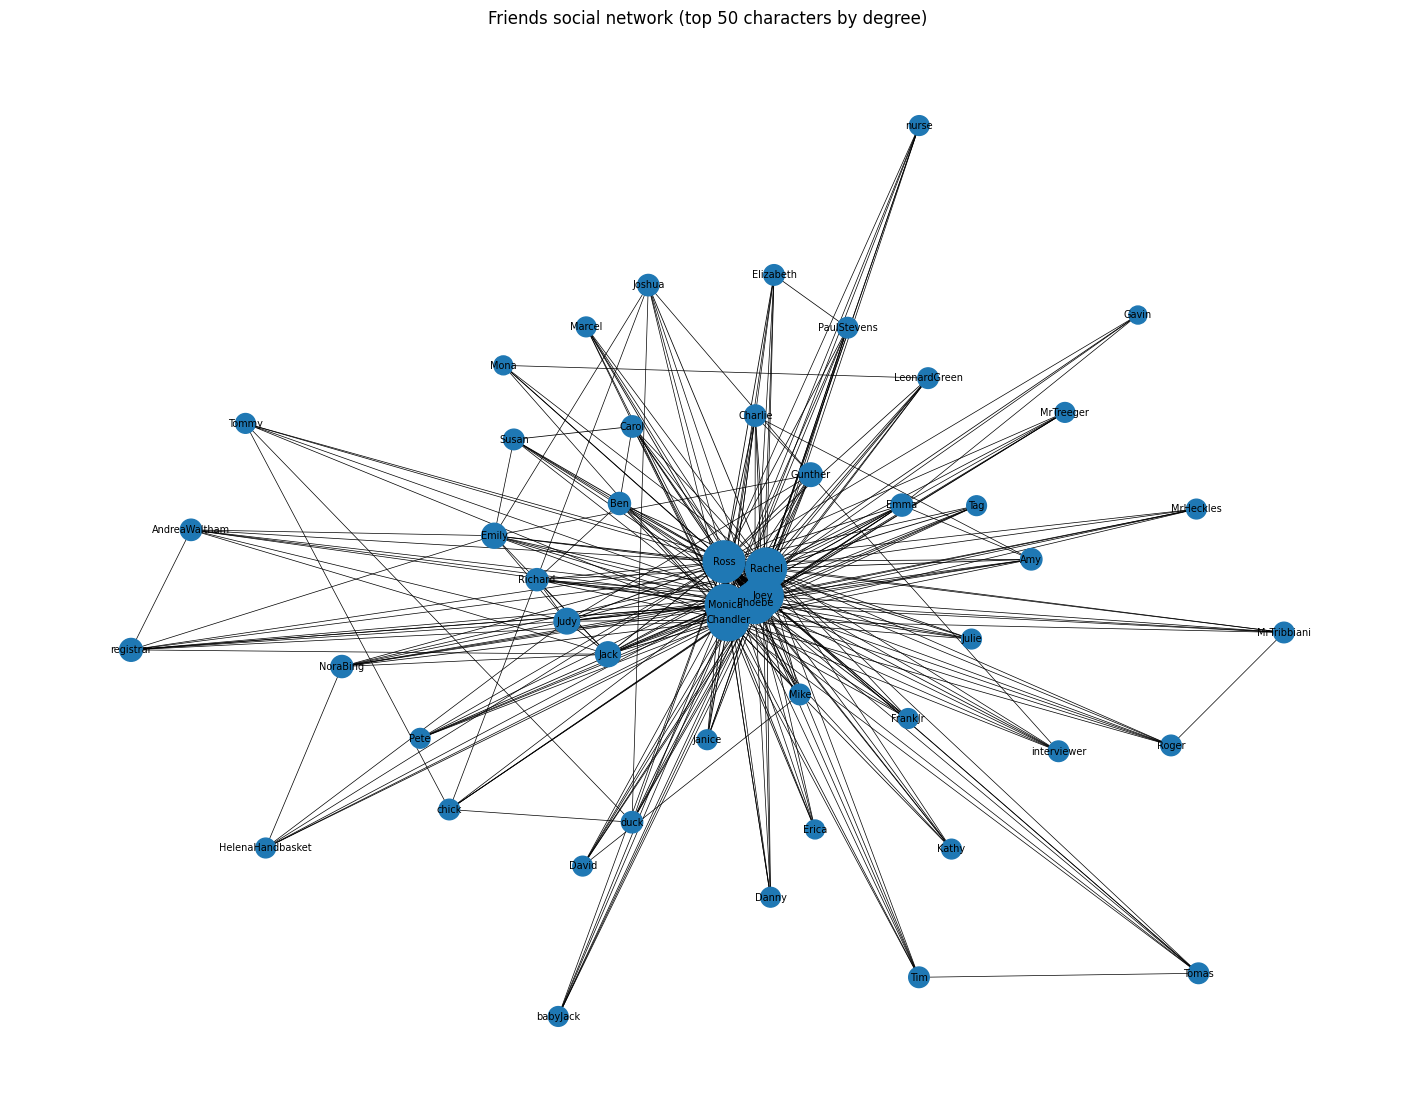

In [ ]:
# Step 1: Get all nodes with their degree
degree_list = list(G.degree())

# Step 2: Sort nodes by degree (highest first)
degree_list_sorted = sorted(degree_list, key=lambda x: x[1], reverse=True)

# Step 3: Take only the top 50 nodes to make it more clear
top_50 = degree_list_sorted[:50]

# Step 4: Extract only the node names
top_nodes = []
for node, degree in top_50:
    top_nodes.append(node)

# Step 5: Create a subgraph with only these nodes
H = G.subgraph(top_nodes)

# Step 6: Implement the edge weights and scale them for visualization
edge_widths = []
for u, v in H.edges():
    w = H[u][v]['weight']
    edge_widths.append(0.5 + 4.5 * (w / max(H[u][v]['weight'] for u, v in H.edges())))

# Step 7: scale the node sizes by degree
max_degree = max(dict(H.degree()).values())
node_sizes = []
for node in H.nodes():
    node_sizes.append(100 + 800 * (H.degree(node) / max_degree))

# Step 6: Draw the subgraph
plt.figure(figsize=(18, 14))
pos = nx.spring_layout(H, seed=42)

nx.draw_networkx_nodes(H, pos, node_size=node_sizes)
nx.draw_networkx_edges(H, pos, width=edge_widths, alpha=1)
nx.draw_networkx_labels(H, pos, font_size=7)

plt.title("Friends social network (top 50 characters by degree)")
plt.axis("off")
plt.show()

In [ ]:
# we check if the graph is directed or undirected
if G.is_directed():
    print("The graph is directed.")
else:
    print("The graph is undirected.")

# we comupte the number of nodes
number_of_nodes = G.number_of_nodes()
print("Number of nodes :", number_of_nodes)

# we compute the number of edges
number_of_edges = G.number_of_edges()
print("Number of edges :", number_of_edges)

# we compute the average degree
total_degree = 0
for node in G.nodes():
    total_degree += G.degree(node)

average_degree = total_degree / number_of_nodes
print("Average degree:", average_degree)

# we compute the density
graph_density = nx.density(G)
print("Density of the graph:", graph_density)

The graph is undirected.
Number of nodes : 747
Number of edges : 1610
Average degree: 4.310575635876841
Density of the graph: 0.0057782515226231105


The network is undirected because an edge represents an interaction between two characters and there is no direction in the relationship.

The network contains 747 nodes and 1610 edges
This means there are 747 different characters and 1610 connections between them.

The average degree is 4.31, that means that on average each character has a interaction with with about 4 other characters.

The density is 0.0058, which is very low.
that means that there is only a very small number of all possible connections that actually exist.

This is typical for social networks, because not every character interacts with every other character.

WEEK 2

In [ ]:
import networkx as nx

# Largest connected component (because we have a undirected graph)
largest_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_nodes).copy()

print("Largest component nodes:", G_lcc.number_of_nodes())
print("Largest component edges:", G_lcc.number_of_edges())

Largest component nodes: 747
Largest component edges: 1610


In [ ]:
def clustering_all_nodes(graph):
    clustering = {}  # node to clustering coefficient

    for v in graph.nodes():
        neighbors = list(graph.neighbors(v))
        k = len(neighbors)

        # if degree is smaller than 2 then no triangles possible
        if k < 2:
            clustering[v] = 0.0
            continue

        # count edges among neighbors
        links = 0
        for i in range(k):
            for j in range(i + 1, k):
                u = neighbors[i]
                w = neighbors[j]
                if graph.has_edge(u, w):
                    links += 1

        # maximum possible links among neighbors
        max_links = k * (k - 1) / 2

        clustering[v] = links / max_links

    return clustering

In [ ]:
def average_clustering(graph):
    C = clustering_all_nodes(graph)
    return sum(C.values()) / len(C)

In [ ]:
C_our = clustering_all_nodes(G_lcc)
avg_our = average_clustering(G_lcc)

print("Our Average clustering:", avg_our)

Our Average clustering: 0.5002643179271572


In [ ]:
avg_nx = nx.average_clustering(G_lcc)
trans_nx = nx.transitivity(G_lcc)

print("Our average clustering:     ", avg_our)
print("NetworkX average clustering:", avg_our)
print("NetworkX transitivity:      ", trans_nx)
print("Difference between our and NetworkX :", abs(avg_our - avg_nx))

Our average clustering:      0.5002643179271572
NetworkX average clustering: 0.5002643179271572
NetworkX transitivity:       0.0335009492845488
Difference between our and NetworkX : 0.0


We implemented our own function to compute the clustering coefficient at each node and then computed the average clustering.
We compared our result with the python libery NetworkX function to verify if it's correct.
Since there isn't our function is equal to NetworkX, then our implementation is correct.

WEEK 3

In [ ]:
# Cumulative distribution of clustering coefficients

C = clustering_all_nodes(G_lcc)

clustering_values = sorted(C.values())
n = len(clustering_values)
cdf_c = [i / n for i in range(1, n + 1)]

In [ ]:
# Average neighbor clustering per node + its CDF

def neighbor_avg_clustering(graph, clustering):
    neighbor_avg = {}
    for v in graph.nodes():
        neighbors = list(graph.neighbors(v))
        if len(neighbors) == 0:
            neighbor_avg[v] = 0.0
        else:
            neighbor_avg[v] = sum(clustering[u] for u in neighbors) / len(neighbors)
    return neighbor_avg

N_avg = neighbor_avg_clustering(G_lcc, C)

neighbor_values = sorted(N_avg.values())
cdf_n = [i / n for i in range(1, n + 1)]

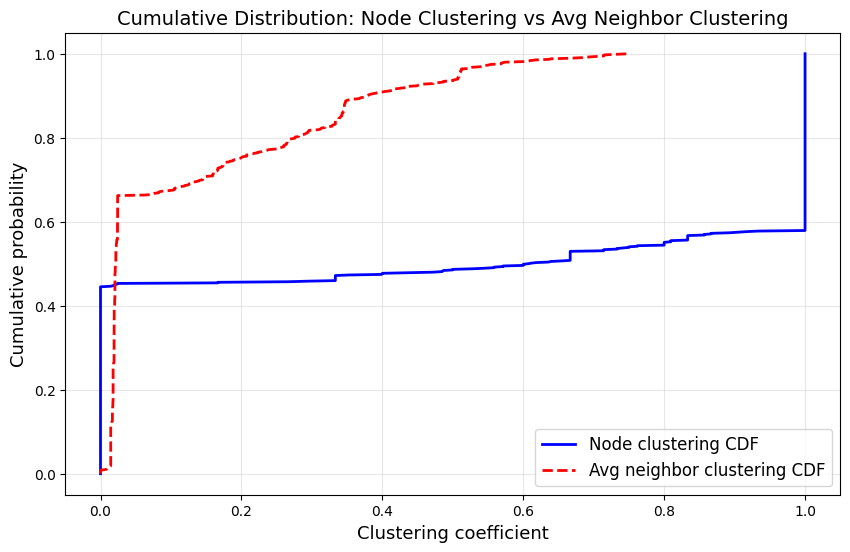

In [ ]:
# Compare the two distributions via graph

plt.figure(figsize=(10, 6))
plt.plot(clustering_values, cdf_c, color='blue', linewidth=2, label='Node clustering CDF')
plt.plot(neighbor_values, cdf_n, color='red', linewidth=2, linestyle='--', label='Avg neighbor clustering CDF')

plt.xlabel('Clustering coefficient', fontsize=13)
plt.ylabel('Cumulative probability', fontsize=13)
plt.title('Cumulative Distribution: Node Clustering vs Avg Neighbor Clustering', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

We computed the cumulative distribution of the clustering coefficients for every node in the largest connected component. Then we defined for each node the average clustering of its neighbors and computed its cumulative distribution as well.
When we compared the two distributions, we can see that the neighbor clustering curve is shifted to the right, meaning that neighbors are more likly to have a higher clustering than the nodes themselves.

WEEK 5:

In [ ]:
# We chose Betweenness and Closeness centrality as the two most relevant
# local notions for a social interaction network as Friends

# A. Betweenness Centrality
# We will measures how often a node lies on the shortest path between two other nodes.

betweenness = nx.betweenness_centrality(G_lcc)
top10_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 - Betweenness Centrality:")
for node, score in top10_betweenness:
    print(f"  {node}: {round(score, 4)}")

# B. Closeness Centrality
# We measures how quickly a node can reach all other nodes in the network.

closeness = nx.closeness_centrality(G_lcc)
top10_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 - Closeness Centrality:")
for node, score in top10_closeness:
    print(f"  {node}: {round(score, 4)}")

Top 10 - Betweenness Centrality:
  Joey: 0.3238
  Ross: 0.2718
  Rachel: 0.2382
  Chandler: 0.2312
  Phoebe: 0.1907
  Monica: 0.1832
  Mike: 0.0083
  Richard: 0.0064
  Joshua: 0.0059
  Pete: 0.0058

Top 10 - Closeness Centrality:
  Joey: 0.6016
  Ross: 0.5916
  Chandler: 0.5851
  Rachel: 0.5846
  Monica: 0.5703
  Phoebe: 0.5703
  Judy: 0.495
  Jack: 0.494
  Gunther: 0.494
  Emily: 0.4934


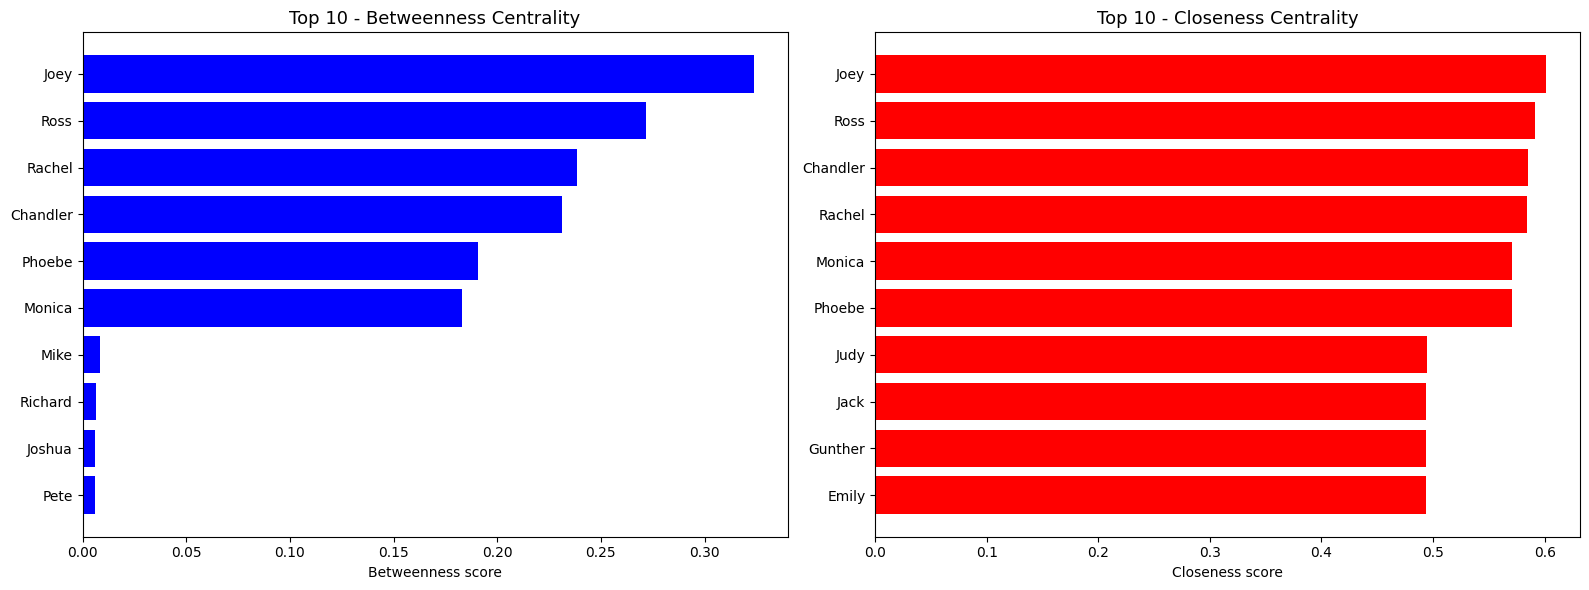

In [29]:
# Visualize the most central nodes

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

nodes_b = [x[0] for x in top10_betweenness]
scores_b = [x[1] for x in top10_betweenness]
axes[0].barh(nodes_b[::-1], scores_b[::-1], color='blue')
axes[0].set_title('Top 10 - Betweenness Centrality', fontsize=13)
axes[0].set_xlabel('Betweenness score')

nodes_c = [x[0] for x in top10_closeness]
scores_c = [x[1] for x in top10_closeness]
axes[1].barh(nodes_c[::-1], scores_c[::-1], color='red')
axes[1].set_title('Top 10 - Closeness Centrality', fontsize=13)
axes[1].set_xlabel('Closeness score')

plt.tight_layout()
plt.show()

We compute two centrality measures on the largest connected component, betweenness and Closeness centrality. Both measures consistently identify the 6 main characters (Joey, Ross, Rachel, Chandler, Monica, Phoebe) as the most central nodes. Joey ranks first in both, meaning he is as the same time the most connected to the others and also can reasch any other node the fastest. The gap between the main cast and secondary characters is large, confirming that the network is built around a tight central core.